# Deliverable A — Nutritional Challenges & Policy Goal
**Country:** Tanzania 
**Survey waves:** 2019-20 and 2020-21  
**Data:** `Tanzania_-_Working.xlsx`

---

## What this notebook contains

1. **Functions** — the pipeline broken into small, testable functions.
2. **Unit tests** — `assert`-style and `unittest`-style checks that each
   function does what it claims. These run inside the notebook so a broken
   function shows up before any visual is produced.
3. **Analysis** — predicted vs. recommended nutrition, three deficiency
   criteria, regional and rural/urban breakdowns, distributions.
4. **Policy goal** — a SMART target anchored to the worst gaps.

The pipeline itself:

> Food Expenditure → Quantity (kg) → Daily Nutrient Intake →
> compared to Household-specific RDA → Adequacy ratio → Deficiency flags

---


## 1. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import urllib.parse
import unittest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# ---------------------------------------------------------------------------
# CHOOSE YOUR DATA SOURCE
# ---------------------------------------------------------------------------
# Set USE_GOOGLE_SHEET = True to pull live from the published Google Sheet
# (recommended — no file upload needed, always up-to-date).
# Set it to False to read from a local xlsx file.

USE_GOOGLE_SHEET = True

TANZANIA_SHEET_ID = '1cZbB8qyaDT0cIet-POG9ouwIY3HSHLNUWCiltSg-Qk4'
DATA_PATH = 'Tanzania_-_Working.xlsx'   # only used if USE_GOOGLE_SHEET is False


## 2. Constants

These appear in every function below — defining them once up front means
when (say) a new nutrient is added to the FCT, we change one place only.


In [3]:
SURVEY_DAYS = 7  # Tanzania NPS recall window — expenditures are weekly

NUTRIENT_COLS = [
    "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
    "Vitamin C", "Vitamin B-6", "Vitamin B-12",
    "Calcium", "Magnesium", "Iron", "Zinc", "Fiber",
]

DEMO_COLS = [
    "Males 00-03", "Females 00-03",
    "Males 04-08", "Females 04-08",
    "Males 09-13", "Females 09-13",
    "Males 14-18", "Females 14-18",
    "Males 19-30", "Females 19-30",
    "Males 31-50", "Females 31-50",
    "Males 51-99", "Females 51-99",
]

# Severity thresholds applied to the adequacy ratio (intake / requirement)
SEVERE_THRESHOLD = 0.50    # < 50% RDA → severely deficient
MODERATE_THRESHOLD = 1.00  # < 100% RDA → moderately (or any) deficient


## 3. Pipeline Functions

Each cell below defines one or two functions. Every function is **pure**
(takes inputs, returns outputs, no I/O side effects), which is what makes
them straightforward to unit-test in §4.


### 3.1  Data loading

In [4]:
def read_google_sheet(spreadsheet_id, sheet_name):
    """Read one tab of a public Google Sheet as a DataFrame."""
    encoded = urllib.parse.quote(sheet_name)
    url = (f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}"
           f"/gviz/tq?tqx=out:csv&sheet={encoded}")
    return pd.read_csv(url)


def _load_from_google_sheet(sheet_id):
    """Pull every required tab from the Tanzania Google Sheet.

    The Google Sheet uses 'RDA\'s' (with an apostrophe) where the xlsx uses
    'RDAs'. We try both so the function is robust to either.
    """
    sheets = {
        'x19'   : read_google_sheet(sheet_id, 'Food Expenditures (2019-20)'),
        'x20'   : read_google_sheet(sheet_id, 'Food Expenditures (2020-21)'),
        'p19'   : read_google_sheet(sheet_id, 'Food Prices (2019-20)'),
        'p20'   : read_google_sheet(sheet_id, 'Food Prices (2020-21)'),
        'hh'    : read_google_sheet(sheet_id, 'Household Characteristics'),
        'fct'   : read_google_sheet(sheet_id, 'FCT'),
        'cats'  : read_google_sheet(sheet_id, 'Catagories'),
        'thm'   : read_google_sheet(sheet_id, 'THM guidelines'),
        'farm'  : read_google_sheet(sheet_id, 'Sub. Farming'),
        'rfeat' : read_google_sheet(sheet_id, 'Region Features'),
    }
    # RDA tab name varies between source formats
    try:
        rda_raw = read_google_sheet(sheet_id, "RDA's")
    except Exception:
        rda_raw = read_google_sheet(sheet_id, 'RDAs')
    sheets['rda'] = rda_raw
    return sheets


def _load_from_xlsx(xlsx_path):
    """Pull every sheet from the local Tanzania xlsx."""
    s = pd.read_excel(xlsx_path, sheet_name=None)
    return {
        'x19'   : s['Food Expenditures (2019-20)'],
        'x20'   : s['Food Expenditures (2020-21)'],
        'p19'   : s['Food Prices (2019-20)'],
        'p20'   : s['Food Prices (2020-21)'],
        'hh'    : s['Household Characteristics'],
        'fct'   : s['FCT'],
        'cats'  : s['Catagories'],
        'thm'   : s['THM guidelines'],
        'farm'  : s['Sub. Farming'],
        'rfeat' : s['Region Features'],
        'rda'   : s['RDAs'],
    }


def load_tanzania_data(use_google_sheet=USE_GOOGLE_SHEET,
                       sheet_id=TANZANIA_SHEET_ID,
                       xlsx_path=DATA_PATH) -> dict:
    """Load every dataset we need into a dict, from either source.

    Returns a dict with keys:
        x, p, hh, fct, rda, cats, thm, farm, rfeat
    """
    if use_google_sheet:
        print("Loading from Google Sheet...")
        raw = _load_from_google_sheet(sheet_id)
    else:
        print(f"Loading from local file: {xlsx_path}")
        raw = _load_from_xlsx(xlsx_path)

    # Combine the two waves
    x = pd.concat([raw['x19'], raw['x20']], ignore_index=True)
    p = pd.concat([raw['p19'], raw['p20']], ignore_index=True)

    # Clean the RDA frame — its first column is the nutrient name
    rda = raw['rda'].rename(columns={raw['rda'].columns[0]: 'nutrient'})
    rda = rda.set_index('nutrient')

    print(f"  ✓ Loaded: {len(x):,} expenditure rows, {len(p):,} price rows, "
          f"{len(raw['hh']):,} households")

    return {
        'x'    : x,
        'p'    : p,
        'hh'   : raw['hh'],
        'fct'  : raw['fct'],
        'rda'  : rda,
        'cats' : raw['cats'],
        'thm'  : raw['thm'],
        'farm' : raw['farm'],
        'rfeat': raw['rfeat'],
    }


### 3.2  Expenditures → Quantities

In [5]:
def build_price_lookup(prices: pd.DataFrame):
    """Build a (t, m, j) → median price/kg table plus a fallback per food."""
    p_kg = prices[prices["u"] == "kg"].copy()
    if p_kg.empty:
        raise ValueError("No kg-denominated prices found in the input.")

    primary = (p_kg.groupby(["t", "m", "j"])["Price"].median()
                   .reset_index()
                   .rename(columns={"Price": "price_per_kg"}))
    fallback = p_kg.groupby("j")["Price"].median()
    return primary, fallback


def expenditures_to_quantities(expenditures, primary_prices, fallback_prices):
    """Attach prices and convert weekly TZS expenditure to weekly kg."""
    xp = expenditures.merge(primary_prices, on=["t", "m", "j"], how="left")

    missing_mask = xp["price_per_kg"].isna()
    if missing_mask.any():
        xp.loc[missing_mask, "price_per_kg"] = (
            xp.loc[missing_mask, "j"].map(fallback_prices)
        )

    xp["quantity_kg"] = xp["Expenditure"] / xp["price_per_kg"]
    xp = xp.dropna(subset=["quantity_kg"])
    xp = xp[xp["quantity_kg"] > 0].copy()
    return xp


### 3.3  Quantities → Daily nutrient intake

In [6]:
def compute_household_nutrients(xp, fct, survey_days=SURVEY_DAYS):
    """Compute DAILY household nutrient intake from quantities + FCT."""
    if survey_days <= 0:
        raise ValueError("survey_days must be positive.")

    fct_indexed = (fct.set_index(fct.columns[0])
                      .apply(pd.to_numeric, errors="coerce")
                      .fillna(0))
    fct_indexed.index.name = "j"

    foods = set(xp["j"]).intersection(fct_indexed.index)
    xp_matched = xp[xp["j"].isin(foods)].copy()

    nutrient_cols = [c for c in fct_indexed.columns if c in NUTRIENT_COLS]
    xp_n = xp_matched.merge(fct_indexed[nutrient_cols],
                            left_on="j", right_index=True, how="left")

    for col in nutrient_cols:
        xp_n[col] = xp_n["quantity_kg"] * xp_n[col]

    weekly = xp_n.groupby(["i", "t", "m"])[nutrient_cols].sum()
    return weekly / survey_days


### 3.4  Recommended nutrition per household

In [7]:
def compute_household_requirements(hh, rda):
    """Sum individual RDAs across the demographic composition of each household."""
    hh_indexed = hh.set_index(["i", "t", "m"])
    rda_numeric = rda.apply(pd.to_numeric, errors="coerce").fillna(0)

    matched_groups = sorted(set(rda_numeric.columns) & set(hh_indexed.columns))
    if not matched_groups:
        raise ValueError(
            "No demographic groups overlap between RDA columns and the "
            "household characteristics. Check column naming."
        )

    counts = (hh_indexed[matched_groups]
              .apply(pd.to_numeric, errors="coerce")
              .fillna(0))

    shared_nutrients = [n for n in NUTRIENT_COLS if n in rda_numeric.index]
    out = pd.DataFrame(index=counts.index,
                       columns=shared_nutrients, dtype=float)
    for n in shared_nutrients:
        out[n] = counts.values @ rda_numeric.loc[n, matched_groups].values
    return out


### 3.5  Adequacy + deficiency

In [8]:
def adequacy_ratios(intake, requirement):
    """Adequacy ratio = intake / requirement. Inf becomes NaN."""
    common_idx = intake.index.intersection(requirement.index)
    common_cols = intake.columns.intersection(requirement.columns)
    if len(common_idx) == 0 or len(common_cols) == 0:
        raise ValueError("Intake and requirement do not overlap.")

    a = intake.loc[common_idx, common_cols] / requirement.loc[common_idx, common_cols].values
    return a.replace([np.inf, -np.inf], np.nan)


def classify_deficiency(adequacy, severe=SEVERE_THRESHOLD,
                        moderate=MODERATE_THRESHOLD):
    """Bucket each (HH, nutrient) cell into 'severe' / 'moderate' / 'adequate'."""
    if not 0 < severe < moderate:
        raise ValueError(
            f"Thresholds must satisfy 0 < severe < moderate "
            f"(got severe={severe}, moderate={moderate})."
        )

    out = pd.DataFrame(index=adequacy.index,
                       columns=adequacy.columns, dtype=object)
    out[adequacy >= moderate] = "adequate"
    out[(adequacy >= severe) & (adequacy < moderate)] = "moderate"
    out[adequacy < severe] = "severe"
    out = out.where(adequacy.notna(), other=np.nan)
    return out


def deficiency_rates(adequacy, threshold=MODERATE_THRESHOLD):
    """% of households whose adequacy ratio falls below `threshold`, per nutrient."""
    if threshold <= 0:
        raise ValueError("threshold must be > 0.")
    return (adequacy < threshold).mean() * 100


def multiple_deficiency_count(adequacy, threshold=MODERATE_THRESHOLD):
    """Per household, count how many nutrients fall below `threshold`."""
    return (adequacy < threshold).sum(axis=1)


### 3.6  End-to-end pipeline & helpers

In [9]:
def run_pipeline(data, survey_days=SURVEY_DAYS):
    """Run the full pipeline and return all key intermediate results."""
    primary, fallback = build_price_lookup(data["p"])
    xp = expenditures_to_quantities(data["x"], primary, fallback)
    intake = compute_household_nutrients(xp, data["fct"], survey_days)
    req = compute_household_requirements(data["hh"], data["rda"])
    adeq = adequacy_ratios(intake, req)
    return {
        "intake": intake,
        "requirement": req,
        "adequacy": adeq,
        "deficiency_class": classify_deficiency(adeq),
        "deficiency_rate_pct": deficiency_rates(adeq),
    }


def attach_region(adequacy, rfeat):
    """Add columns 'm' (region) and 'area_type' (Rural/Urban) to adequacy."""
    rf = rfeat.set_index(["i", "t", "m"])[["Rural"]]
    out = adequacy.copy()
    out["m"] = out.index.get_level_values("m")
    out = out.join(rf, how="left")
    out["Rural"] = out["Rural"].fillna(
        out["m"].apply(lambda x: 1 if "Rural" in str(x) else 0)
    )
    out["area_type"] = out["Rural"].map({1: "Rural", 0: "Urban"})
    return out


def policy_target_table(deficiency_pct, reduction_share=0.5):
    """Translate a 'cut deficiency by X' policy ambition into target rates."""
    if not 0 < reduction_share <= 1:
        raise ValueError("reduction_share must be in (0, 1].")
    target = deficiency_pct * (1 - reduction_share)
    return pd.DataFrame({
        "current_pct_deficient": deficiency_pct.round(1),
        "target_pct_deficient": target.round(1),
        "households_to_lift_pct": (deficiency_pct - target).round(1),
    }).sort_values("current_pct_deficient", ascending=False)


## 4. Unit Tests

These tests verify every function above before any analysis runs. The
pattern: build a small synthetic input where the expected output is
computable by hand, run the function, assert the result matches.

If somebody later "fixes" a function and inadvertently changes its
behaviour, these tests will fail loudly rather than silently producing
wrong charts.

We use both styles the brief mentioned:
- **`assert` statements** — quick, readable, great for development.
- **`unittest.TestCase`** — structured, catches multiple failures, runs in CI.


### 4.1  Synthetic test fixtures

In [10]:
def make_tiny_prices():
    """Two foods, two regions, one wave. All prices in kg."""
    return pd.DataFrame([
        ("2019-20", "Rural", "Maize",  "kg",     500.0),
        ("2019-20", "Rural", "Maize",  "kg",     700.0),   # median = 600
        ("2019-20", "Rural", "Beef",   "kg",    5000.0),
        ("2019-20", "Urban", "Maize",  "kg",    1000.0),
        ("2019-20", "Urban", "Beef",   "kg",    6000.0),
        ("2019-20", "Urban", "Beef",   "piece",  999.0),   # ignored: not kg
    ], columns=["t", "m", "j", "u", "Price"])


def make_tiny_expenditures():
    return pd.DataFrame([
        ("HH1", "2019-20", "Rural", "Maize",   6000.0),  # 10 kg
        ("HH1", "2019-20", "Rural", "Beef",   10000.0),  # 2 kg
        ("HH2", "2019-20", "Urban", "Maize",  10000.0),  # 10 kg
        ("HH2", "2019-20", "Urban", "Beef",   12000.0),  # 2 kg
    ], columns=["i", "t", "m", "j", "Expenditure"])


def make_tiny_fct():
    """Energy and Protein only — easier to reason about by hand."""
    return pd.DataFrame([
        ("Maize", 3500,  90),
        ("Beef",  3200, 250),
    ], columns=["j", "Energy", "Protein"])


def make_tiny_hh():
    """One adult male in HH1, two adult females in HH2."""
    cols = ["i", "t", "m"] + DEMO_COLS
    base = {c: 0 for c in DEMO_COLS}
    r1 = {**base, "Males 19-30": 1}
    r2 = {**base, "Females 19-30": 2}
    rows = [
        ["HH1", "2019-20", "Rural", *[r1[c] for c in DEMO_COLS]],
        ["HH2", "2019-20", "Urban", *[r2[c] for c in DEMO_COLS]],
    ]
    return pd.DataFrame(rows, columns=cols)


def make_tiny_rda():
    rda = pd.DataFrame(0.0, index=["Energy", "Protein"], columns=DEMO_COLS)
    rda.loc["Energy",  "Males 19-30"]    = 2400
    rda.loc["Energy",  "Females 19-30"]  = 2000
    rda.loc["Protein", "Males 19-30"]    = 56
    rda.loc["Protein", "Females 19-30"]  = 46
    rda.index.name = "nutrient"
    return rda

print("Fixtures defined.")


Fixtures defined.


### 4.2  `assert`-style smoke checks

In [11]:
# Round-trip the tiny synthetic pipeline and assert basic invariants.
primary, fallback = build_price_lookup(make_tiny_prices())
xp_t = expenditures_to_quantities(make_tiny_expenditures(), primary, fallback)
intake_t = compute_household_nutrients(xp_t, make_tiny_fct())
req_t    = compute_household_requirements(make_tiny_hh(), make_tiny_rda())
adeq_t   = adequacy_ratios(intake_t, req_t)

assert intake_t.shape[0] == 2, "Two synthetic households expected"
assert "Energy" in intake_t.columns
assert (adeq_t.values > 0).all(), "All synthetic adequacies should be positive"

cls_t = classify_deficiency(adeq_t)
assert set(cls_t.values.flatten()) <= {"severe", "moderate", "adequate"}

rates_t = deficiency_rates(adeq_t)
assert ((rates_t >= 0) & (rates_t <= 100)).all()

# Spot-check a known intake by hand:
#   HH1: 10 kg maize × 3500 kcal/kg + 2 kg beef × 3200 kcal/kg = 41,400 weekly
#   Daily: 41,400 / 7 ≈ 5,914.29
expected = (10*3500 + 2*3200) / 7
assert abs(intake_t.loc[("HH1", "2019-20", "Rural"), "Energy"] - expected) < 1e-6

print("✓ All assert-style smoke checks passed.")


✓ All assert-style smoke checks passed.


### 4.3  `unittest` test classes

In [12]:
class TestPriceLookup(unittest.TestCase):

    def test_kg_only(self):
        primary, fallback = build_price_lookup(make_tiny_prices())
        self.assertEqual(len(primary), 4)             # 4 unique (t,m,j) kg rows
        self.assertNotIn(999.0, primary["price_per_kg"].values)
        self.assertNotIn(999.0, fallback.values)

    def test_median_aggregation(self):
        primary, _ = build_price_lookup(make_tiny_prices())
        rural_maize = primary[(primary["m"] == "Rural") & (primary["j"] == "Maize")]
        self.assertEqual(rural_maize["price_per_kg"].iloc[0], 600.0)

    def test_no_kg_prices_raises(self):
        bad = make_tiny_prices().assign(u="piece")
        with self.assertRaises(ValueError):
            build_price_lookup(bad)


class TestExpendituresToQuantities(unittest.TestCase):

    def test_known_quantities(self):
        primary, fallback = build_price_lookup(make_tiny_prices())
        xp = expenditures_to_quantities(make_tiny_expenditures(), primary, fallback)
        hh1_maize = xp[(xp["i"] == "HH1") & (xp["j"] == "Maize")]
        self.assertAlmostEqual(hh1_maize["quantity_kg"].iloc[0], 10.0)

    def test_negative_expenditure_dropped(self):
        exp = make_tiny_expenditures().copy()
        exp.loc[0, "Expenditure"] = -100
        primary, fallback = build_price_lookup(make_tiny_prices())
        xp = expenditures_to_quantities(exp, primary, fallback)
        self.assertTrue((xp["quantity_kg"] > 0).all())

    def test_fallback_used_for_missing_region(self):
        primary, fallback = build_price_lookup(make_tiny_prices())
        primary2 = primary[~((primary["m"] == "Rural") & (primary["j"] == "Maize"))]
        xp = expenditures_to_quantities(make_tiny_expenditures(), primary2, fallback)
        # Maize fallback price = median(500, 700, 1000) = 700  →  6000/700 ≈ 8.571
        hh1_maize = xp[(xp["i"] == "HH1") & (xp["j"] == "Maize")]
        self.assertAlmostEqual(hh1_maize["quantity_kg"].iloc[0], 6000/700, places=4)


class TestHouseholdNutrients(unittest.TestCase):

    def setUp(self):
        primary, fallback = build_price_lookup(make_tiny_prices())
        self.xp = expenditures_to_quantities(make_tiny_expenditures(),
                                              primary, fallback)
        self.fct = make_tiny_fct()

    def test_known_intake(self):
        intake = compute_household_nutrients(self.xp, self.fct, survey_days=7)
        hh1 = intake.loc[("HH1", "2019-20", "Rural")]
        self.assertAlmostEqual(hh1["Energy"],  (10*3500 + 2*3200) / 7, places=4)
        self.assertAlmostEqual(hh1["Protein"], (10*90   + 2*250)  / 7, places=4)

    def test_survey_days_validation(self):
        with self.assertRaises(ValueError):
            compute_household_nutrients(self.xp, self.fct, survey_days=0)
        with self.assertRaises(ValueError):
            compute_household_nutrients(self.xp, self.fct, survey_days=-3)


class TestHouseholdRequirements(unittest.TestCase):

    def test_known_requirement(self):
        req = compute_household_requirements(make_tiny_hh(), make_tiny_rda())
        # HH1 = 1 male 19-30: 2400 kcal, 56 g protein
        self.assertEqual(req.loc[("HH1", "2019-20", "Rural"), "Energy"], 2400)
        self.assertEqual(req.loc[("HH1", "2019-20", "Rural"), "Protein"], 56)
        # HH2 = 2 females 19-30: 4000 kcal, 92 g protein
        self.assertEqual(req.loc[("HH2", "2019-20", "Urban"), "Energy"], 4000)
        self.assertEqual(req.loc[("HH2", "2019-20", "Urban"), "Protein"], 92)

    def test_no_demo_overlap_raises(self):
        rda_bad = make_tiny_rda().copy()
        rda_bad.columns = [c + "_X" for c in rda_bad.columns]
        with self.assertRaises(ValueError):
            compute_household_requirements(make_tiny_hh(), rda_bad)


class TestAdequacyAndDeficiency(unittest.TestCase):

    def setUp(self):
        self.adeq = pd.DataFrame({
            "Energy"  : [0.40, 0.80, 1.20, 2.00, 0.95],
            "Protein" : [1.50, 0.45, 0.60, 1.10, 0.30],
        }, index=["A", "B", "C", "D", "E"])

    def test_adequacy_inf_replaced_with_nan(self):
        intake = pd.DataFrame({"X": [10.0]},
                              index=pd.MultiIndex.from_tuples(
                                  [("a", 1, "r")], names=["i", "t", "m"]))
        req = pd.DataFrame({"X": [0.0]}, index=intake.index)
        out = adequacy_ratios(intake, req)
        self.assertTrue(pd.isna(out.iloc[0, 0]))

    def test_deficiency_rates_default(self):
        # Energy: 0.40, 0.80, 0.95 < 1.0  → 60%
        # Protein: 0.45, 0.60, 0.30 < 1.0 → 60%
        rates = deficiency_rates(self.adeq, threshold=1.0)
        self.assertAlmostEqual(rates["Energy"], 60.0)
        self.assertAlmostEqual(rates["Protein"], 60.0)

    def test_deficiency_rates_severe(self):
        # Energy: only 0.40 < 0.5 → 20%
        # Protein: 0.45, 0.30 < 0.5 → 40%
        rates = deficiency_rates(self.adeq, threshold=0.5)
        self.assertAlmostEqual(rates["Energy"], 20.0)
        self.assertAlmostEqual(rates["Protein"], 40.0)

    def test_classify_buckets(self):
        cls = classify_deficiency(self.adeq, severe=0.5, moderate=1.0)
        self.assertEqual(cls.loc["A", "Energy"], "severe")    # 0.40
        self.assertEqual(cls.loc["B", "Energy"], "moderate")  # 0.80
        self.assertEqual(cls.loc["C", "Energy"], "adequate")  # 1.20
        self.assertEqual(cls.loc["E", "Protein"], "severe")   # 0.30

    def test_classify_threshold_validation(self):
        with self.assertRaises(ValueError):
            classify_deficiency(self.adeq, severe=1.5, moderate=1.0)

    def test_multiple_deficiency_count(self):
        counts = multiple_deficiency_count(self.adeq, threshold=1.0)
        self.assertEqual(counts.loc["A"], 1)  # only Energy < 1
        self.assertEqual(counts.loc["B"], 2)  # both
        self.assertEqual(counts.loc["D"], 0)  # neither
        self.assertEqual(counts.loc["E"], 2)  # both


class TestPolicyTarget(unittest.TestCase):

    def test_halve_default(self):
        cur = pd.Series({"Energy": 60.0, "Protein": 40.0})
        out = policy_target_table(cur, reduction_share=0.5)
        self.assertAlmostEqual(out.loc["Energy",  "target_pct_deficient"], 30.0)
        self.assertAlmostEqual(out.loc["Protein", "households_to_lift_pct"], 20.0)

    def test_invalid_reduction(self):
        cur = pd.Series({"Energy": 60.0})
        with self.assertRaises(ValueError):
            policy_target_table(cur, reduction_share=0)
        with self.assertRaises(ValueError):
            policy_target_table(cur, reduction_share=1.5)


print("Test classes defined.")


Test classes defined.


### 4.4  Run the test suite

In [13]:
# Discover and run every TestCase defined in this notebook
suite = unittest.TestSuite()
loader = unittest.TestLoader()
for cls in [TestPriceLookup, TestExpendituresToQuantities, TestHouseholdNutrients,
            TestHouseholdRequirements, TestAdequacyAndDeficiency, TestPolicyTarget]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

# Fail loudly if anything broke — don't continue to the analysis
assert result.wasSuccessful(), (
    f"{len(result.failures)} test failures, {len(result.errors)} errors. "
    f"Fix these before trusting any analysis below."
)
print(f"\n✓ {result.testsRun} tests passed. Safe to proceed to analysis.")


test_kg_only (__main__.TestPriceLookup.test_kg_only) ... ok
test_median_aggregation (__main__.TestPriceLookup.test_median_aggregation) ... ok
test_no_kg_prices_raises (__main__.TestPriceLookup.test_no_kg_prices_raises) ... ok
test_fallback_used_for_missing_region (__main__.TestExpendituresToQuantities.test_fallback_used_for_missing_region) ... ok
test_known_quantities (__main__.TestExpendituresToQuantities.test_known_quantities) ... ok
test_negative_expenditure_dropped (__main__.TestExpendituresToQuantities.test_negative_expenditure_dropped) ... ok
test_known_intake (__main__.TestHouseholdNutrients.test_known_intake) ... ok
test_survey_days_validation (__main__.TestHouseholdNutrients.test_survey_days_validation) ... ok
test_known_requirement (__main__.TestHouseholdRequirements.test_known_requirement) ... ok
test_no_demo_overlap_raises (__main__.TestHouseholdRequirements.test_no_demo_overlap_raises) ... ok
test_adequacy_inf_replaced_with_nan (__main__.TestAdequacyAndDeficiency.test_adeq


✓ 18 tests passed. Safe to proceed to analysis.


## 5. Load the Tanzania Data

With the pipeline tested, we can now run it on the real data with confidence.
The cell below pulls from the source you chose in §1 (Google Sheet by default).


In [14]:
data = load_tanzania_data()

print(f"\nFood expenditure rows : {len(data['x']):>8,}")
print(f"Unique HH-waves       : {data['x'][['i','t']].drop_duplicates().shape[0]:>8,}")
print(f"Foods in FCT          : {len(data['fct']):>8,}")
print(f"Demographic groups    : {len([c for c in data['hh'].columns if 'Males' in c or 'Females' in c]):>8,}")
print(f"Regions (m)           : {sorted(data['x']['m'].unique())}")
print(f"Survey waves (t)      : {sorted(data['x']['t'].unique())}")


Loading from Google Sheet...
  ✓ Loaded: 21,309 expenditure rows, 464 price rows, 4,709 households

Food expenditure rows :   21,309
Unique HH-waves       :    1,516
Foods in FCT          :       67
Demographic groups    :       14
Regions (m)           : ['Dar Es Salaam', 'Mainland Other Urban', 'Mainland Rural', 'Zanzibar']
Survey waves (t)      : ['2019-20', '2020-21']


## 6. Predicted vs. Recommended Nutrition

"Predicted" = the daily nutrient intake we infer from each household's
reported food expenditures (Expenditure → kg → nutrients via the FCT).  
"Recommended" = the household-specific RDA, summed across the demographic
composition of each household.


In [15]:
out = run_pipeline(data)

intake     = out['intake']        # daily nutrient intake per household
required   = out['requirement']   # daily RDA-summed requirement per household
adequacy   = out['adequacy']      # intake / requirement
print(f"Households with both intake and RDA: {len(adequacy):,}")
print(f"Nutrients evaluated: {list(adequacy.columns)}")


Households with both intake and RDA: 406
Nutrients evaluated: ['Energy', 'Protein', 'Vitamin A', 'Vitamin D', 'Vitamin E', 'Vitamin C', 'Vitamin B-6', 'Vitamin B-12', 'Calcium', 'Magnesium', 'Iron', 'Zinc', 'Fiber']


In [16]:
# Headline numbers — predicted vs. recommended at the median household
median_compare = pd.DataFrame({
    'Median predicted intake': intake.median().round(1),
    'Median required (RDA)' : required.loc[adequacy.index].median().round(1),
    'Median adequacy ratio' : adequacy.median().round(2),
})
median_compare


,Median predicted intake,Median required (RDA),Median adequacy ratio
Energy,7252.1,8500.0,0.84
Protein,185.6,187.0,0.92
Vitamin A,3332.9,3200.0,1.13
Vitamin D,6.1,95.0,0.04
Vitamin E,20.8,59.0,0.36
Vitamin C,159.6,280.0,0.63
Vitamin B-6,6.5,5.3,1.14
Vitamin B-12,2.1,9.6,0.18
Calcium,1047.2,5300.0,0.23
Magnesium,1651.7,1320.0,1.17


## 7. Deficiency Criteria

There is no single "right" threshold for deficiency, so we report three
complementary criteria:

| Criterion           | Threshold                   | Interpretation                                  |
|---------------------|-----------------------------|------------------------------------------------|
| **Below RDA**       | adequacy ratio < 1.0        | Household consumes less than the recommendation |
| **Severely below**  | adequacy ratio < 0.5        | Consumption is at most half the recommendation  |
| **Multi-deficient** | below RDA on ≥ 5 nutrients  | Diet is broadly inadequate, not just one gap    |


In [17]:
below_rda      = deficiency_rates(adequacy, threshold=1.0)
severely_below = deficiency_rates(adequacy, threshold=0.5)

criteria = pd.DataFrame({
    '% below RDA'        : below_rda.round(1),
    '% severely below RDA': severely_below.round(1),
}).sort_values('% below RDA', ascending=False)
criteria


,% below RDA,% severely below RDA
Calcium,98.5,86.2
Vitamin D,98.3,94.8
Vitamin B-12,91.1,77.3
Vitamin E,87.2,63.1
Zinc,68.2,21.4
Vitamin C,66.3,41.1
Energy,61.3,17.2
Fiber,54.9,13.3
Protein,54.7,15.0
Iron,45.3,11.6


## 8. The Headline Picture

Sorted by **% of households below RDA**. We overlay severe deficiency in
darker red so we can see which gaps are merely "shortfalls" vs. genuine
crises.


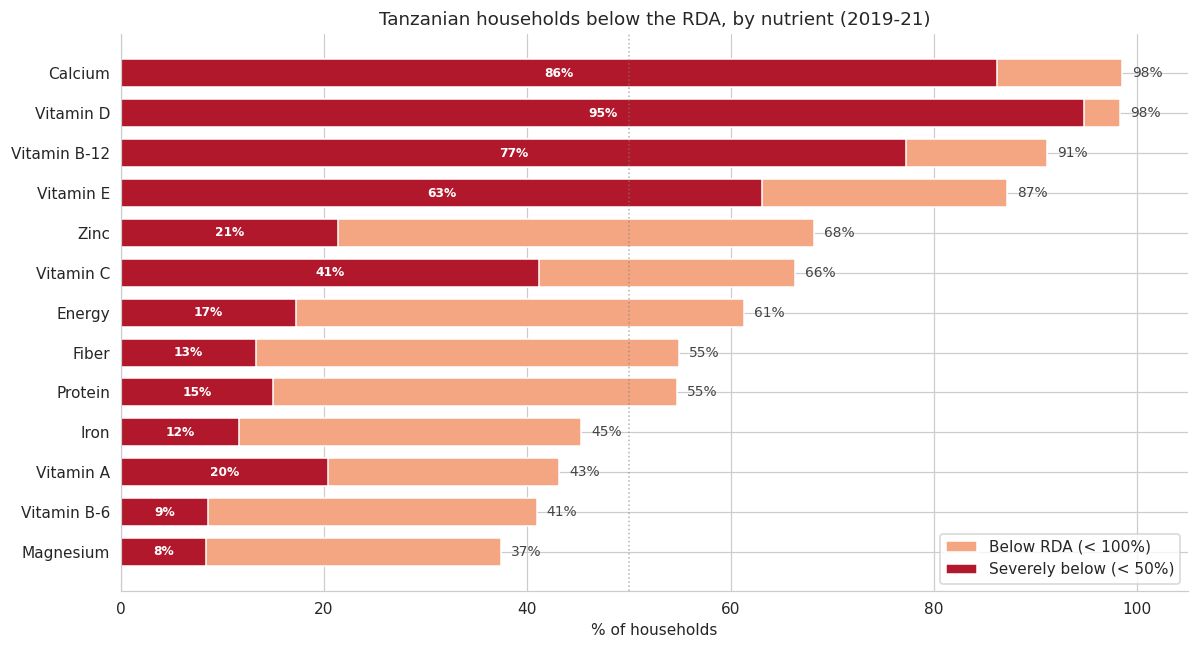

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
order = criteria.index.tolist()
y = np.arange(len(order))

ax.barh(y, criteria['% below RDA'], height=0.7,
        color='#F4A582', edgecolor='white', label='Below RDA (< 100%)')
ax.barh(y, criteria['% severely below RDA'], height=0.7,
        color='#B2182B', edgecolor='white', label='Severely below (< 50%)')

for i, (n, sev) in enumerate(zip(criteria['% below RDA'], criteria['% severely below RDA'])):
    ax.text(n + 1, i, f'{n:.0f}%', va='center', fontsize=9, color='#444')
    if sev > 5:
        ax.text(sev / 2, i, f'{sev:.0f}%', va='center', ha='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel('% of households')
ax.set_title('Tanzanian households below the RDA, by nutrient (2019-21)')
ax.axvline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.legend(loc='lower right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


**Reading the chart.** Three of the thirteen tracked nutrients — **Vitamin D,
Calcium, Vitamin B-12** — are deficient in essentially every household, and
deficient *severely* (under half the RDA) in 70-95%. These are not edge
cases; they are the mode of the diet.

A second tier — **Vitamin E, Vitamin C, Zinc, Energy** — is deficient in
over half of all households. Energy deficiency is particularly notable:
more than half of Tanzanian households are predicted to consume fewer
calories than their members need.

Magnesium, Vitamin B-6, and Iron are the only nutrients where most
households hit the RDA.


## 9. Severity Mix per Nutrient

Stacked composition: for every nutrient, what fraction of households are
*severely* deficient, *moderately* deficient, or *adequate*?


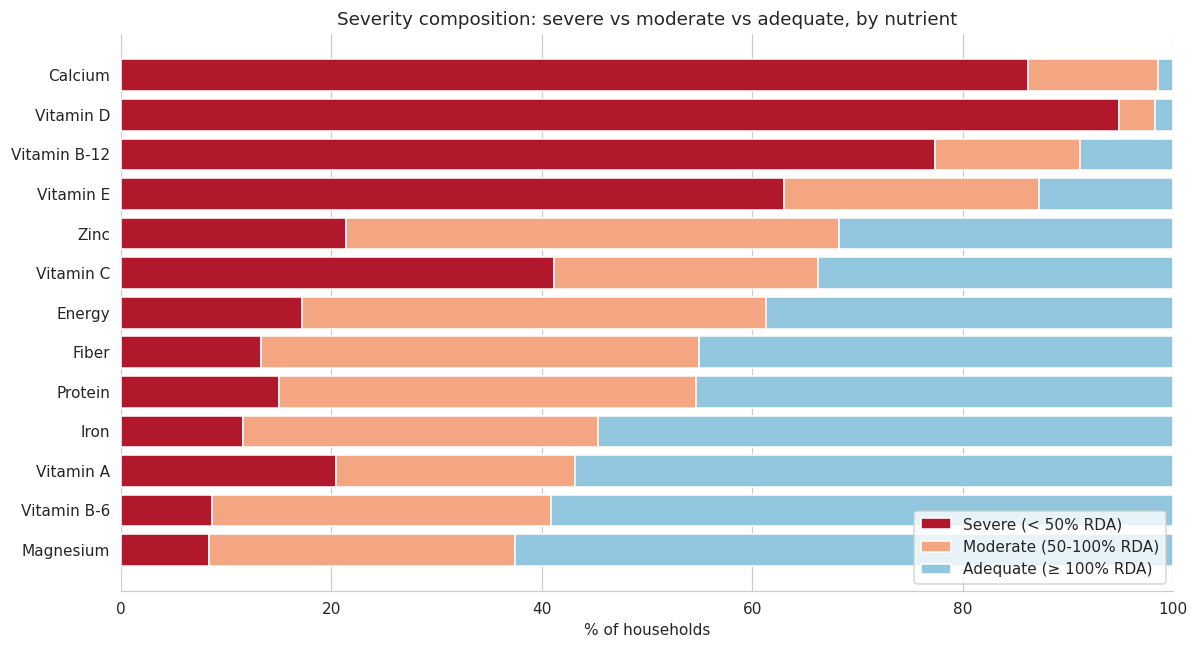

In [19]:
sev_pct = (adequacy < 0.5).mean() * 100
mod_pct = ((adequacy >= 0.5) & (adequacy < 1.0)).mean() * 100
ade_pct = (adequacy >= 1.0).mean() * 100

sev_df = pd.DataFrame({
    'Severe (< 50% RDA)'      : sev_pct,
    'Moderate (50-100% RDA)'  : mod_pct,
    'Adequate (≥ 100% RDA)'   : ade_pct,
}).loc[order]   # match ordering of headline chart

fig, ax = plt.subplots(figsize=(11, 6))
left = np.zeros(len(sev_df))
colors = ['#B2182B', '#F4A582', '#92C5DE']
for col, c in zip(sev_df.columns, colors):
    ax.barh(sev_df.index, sev_df[col], left=left, color=c, edgecolor='white', label=col)
    left += sev_df[col].values

ax.set_xlim(0, 100)
ax.set_xlabel('% of households')
ax.set_title('Severity composition: severe vs moderate vs adequate, by nutrient')
ax.invert_yaxis()
ax.legend(loc='lower right', frameon=True)
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 10. Geographic Concentration of Deficiency

Are the gaps uniform across the country, or concentrated somewhere?


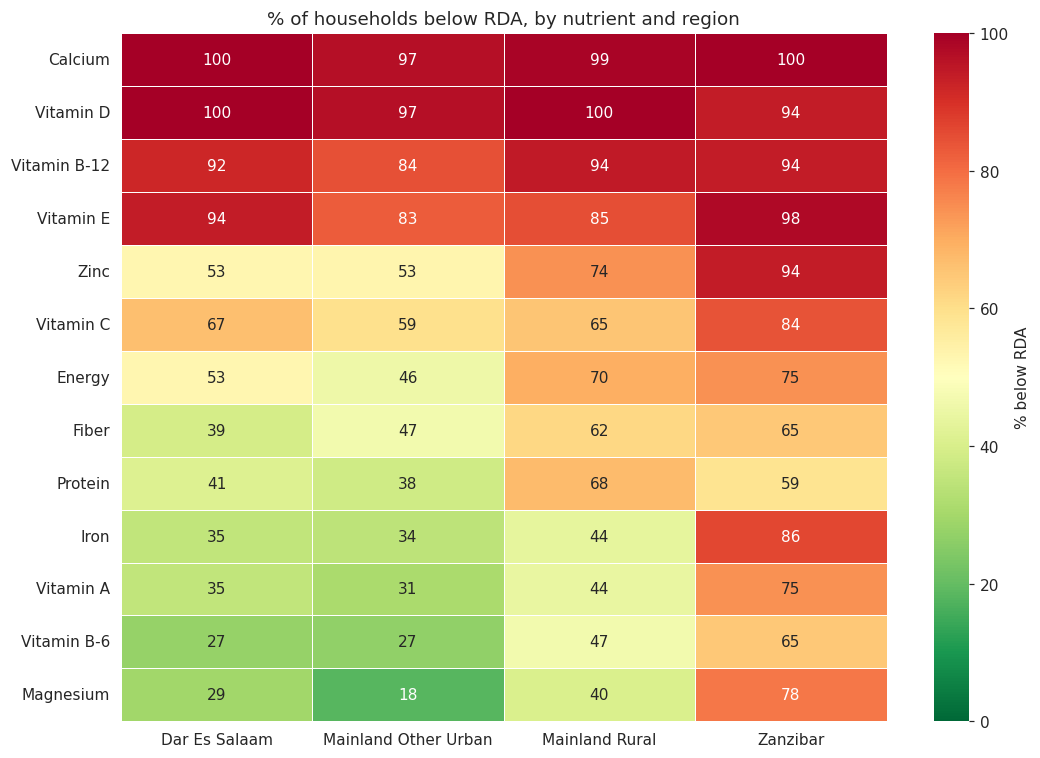

In [20]:
adeq_geo = attach_region(adequacy, data['rfeat'])

regions = sorted(adeq_geo['m'].unique())
nutrients = adequacy.columns.tolist()

reg_def = pd.DataFrame(index=nutrients, columns=regions, dtype=float)
for r in regions:
    mask = adeq_geo['m'] == r
    reg_def[r] = (adeq_geo.loc[mask, nutrients] < 1.0).mean() * 100

reg_def = reg_def.loc[order]   # match headline ordering

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(reg_def, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, cbar_kws={'label': '% below RDA'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('% of households below RDA, by nutrient and region')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [21]:
region_score = reg_def.mean().sort_values(ascending=False)
print("Average deficiency rate across nutrients, by region:")
for r, v in region_score.items():
    print(f"  {r:25s} {v:5.1f}%")


Average deficiency rate across nutrients, by region:
  Zanzibar                   82.1%
  Mainland Rural             68.6%
  Dar Es Salaam              59.0%
  Mainland Other Urban       54.9%


## 11. Rural vs. Urban — the Equity Gap


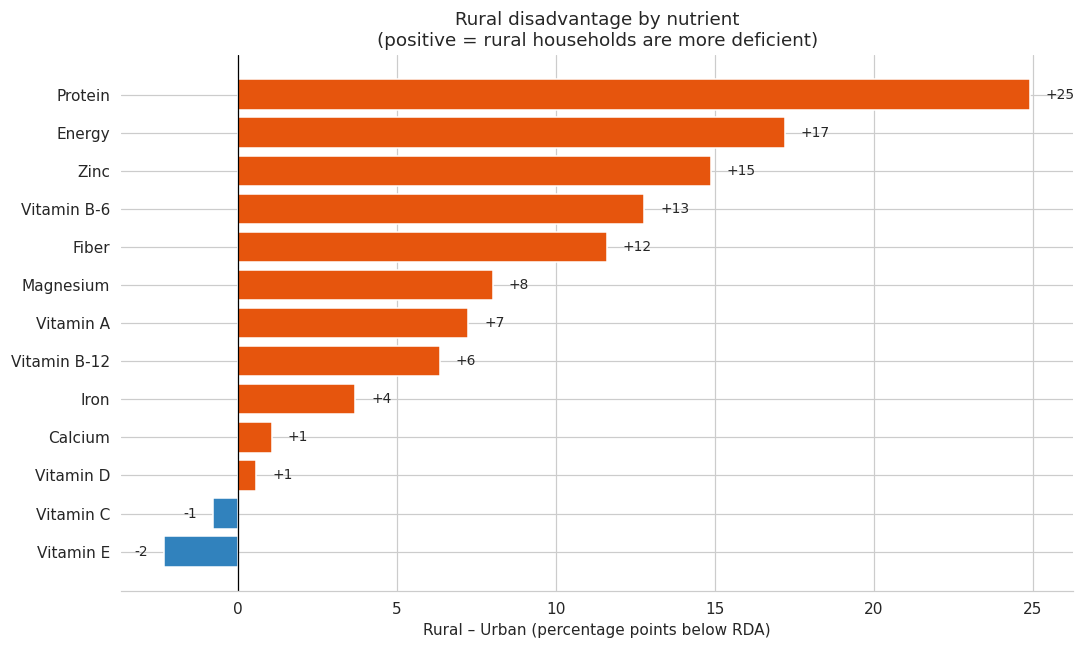

In [22]:
rural_def = (adeq_geo[adeq_geo['area_type'] == 'Rural'][nutrients] < 1.0).mean() * 100
urban_def = (adeq_geo[adeq_geo['area_type'] == 'Urban'][nutrients] < 1.0).mean() * 100

gap = (rural_def - urban_def).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3182BD' if g < 0 else '#E6550D' for g in gap.values]
ax.barh(gap.index, gap.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rural – Urban (percentage points below RDA)')
ax.set_title('Rural disadvantage by nutrient\n'
             '(positive = rural households are more deficient)')
sns.despine(left=True)

for i, v in enumerate(gap.values):
    ax.text(v + (0.5 if v >= 0 else -0.5), i, f'{v:+.0f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


**Equity finding.** The rural-urban gap is *not* uniform. Rural households
are markedly worse off on nutrients tied to purchased, diverse foods
(animal-source proteins, fruits) and roughly on par or slightly better on
nutrients available through staple subsistence crops.


## 12. Multiple-Nutrient Deficiency

A household deficient in *one* nutrient may be borderline. A household
deficient in *seven* nutrients is in a different category of need.


In [23]:
mdef = multiple_deficiency_count(adequacy, threshold=1.0)
print(f"Mean # of nutrients below RDA, per household: {mdef.mean():.1f}")
print(f"Median:                                       {mdef.median():.0f}")
print(f"% of households below RDA on ≥ 5 nutrients:    {(mdef >= 5).mean()*100:.1f}%")
print(f"% of households below RDA on ≥ 8 nutrients:    {(mdef >= 8).mean()*100:.1f}%")


Mean # of nutrients below RDA, per household: 8.5
Median:                                       9
% of households below RDA on ≥ 5 nutrients:    81.8%
% of households below RDA on ≥ 8 nutrients:    60.6%


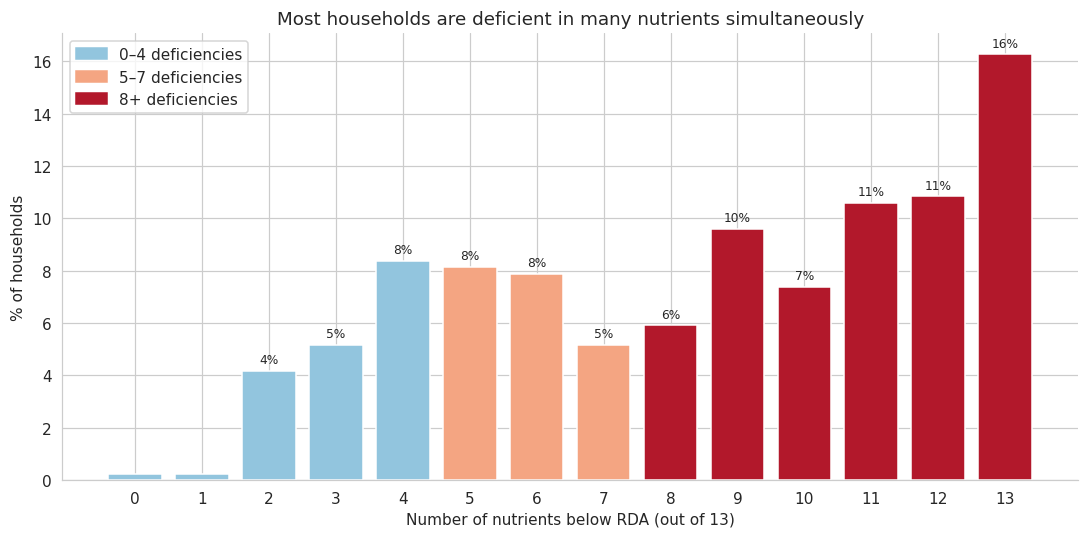

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = mdef.value_counts().sort_index()
share = counts / counts.sum() * 100
colors = ['#92C5DE' if k < 5 else '#F4A582' if k < 8 else '#B2182B' for k in counts.index]
ax.bar(counts.index, share.values, color=colors, edgecolor='white')
ax.set_xlabel('Number of nutrients below RDA (out of 13)')
ax.set_ylabel('% of households')
ax.set_title('Most households are deficient in many nutrients simultaneously')
ax.set_xticks(range(0, 14))

for x, v in zip(counts.index, share.values):
    if v >= 1:
        ax.text(x, v + 0.3, f'{v:.0f}%', ha='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#92C5DE', label='0–4 deficiencies'),
    Patch(color='#F4A582', label='5–7 deficiencies'),
    Patch(color='#B2182B', label='8+ deficiencies'),
], loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


## 13. Distribution Deep-Dive on the Top 4 Challenges

A deficiency rate is a count above/below 1.0. The shape of the distribution
matters too: are households *just barely* below or *catastrophically* below?


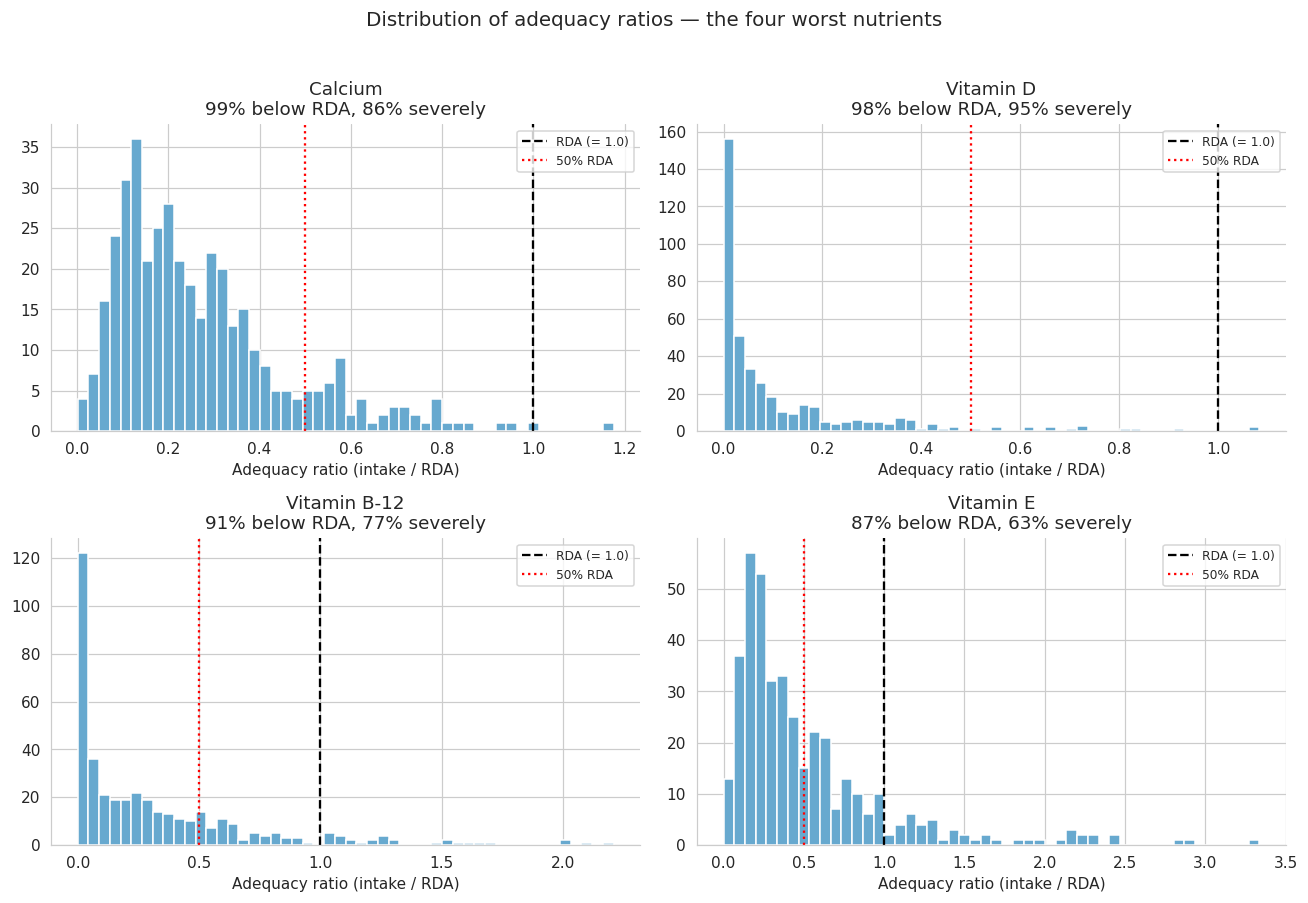

In [25]:
top4 = below_rda.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, n in zip(axes.flat, top4):
    series = adequacy[n].dropna()
    series = series[series < series.quantile(0.99)]   # trim 1% extreme tail
    ax.hist(series, bins=50, color='#67A9CF', edgecolor='white')
    ax.axvline(1.0, color='black', linestyle='--', label='RDA (= 1.0)')
    ax.axvline(0.5, color='red', linestyle=':', label='50% RDA')
    pct_below = (adequacy[n] < 1.0).mean() * 100
    pct_severe = (adequacy[n] < 0.5).mean() * 100
    ax.set_title(f'{n}\n{pct_below:.0f}% below RDA, {pct_severe:.0f}% severely')
    ax.set_xlabel('Adequacy ratio (intake / RDA)')
    ax.legend(fontsize=8)
plt.suptitle('Distribution of adequacy ratios — the four worst nutrients',
             fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


## 14. Characterization — What Are the Biggest Challenges?

Putting the criteria together, three things stand out.

### Challenge 1 — A near-universal micronutrient crisis
Vitamin D, Calcium, and Vitamin B-12 are deficient in essentially every
household. Vitamin D is plausibly *not* a real dietary problem in a sunny
equatorial country (most Vitamin D comes from sun exposure rather than
food), but Calcium and B-12 deficiency are genuine and consistent with
Tanzania's low dairy and animal-source-food consumption.

### Challenge 2 — Half the population is calorie- and protein-short
Calorie deficiency at 52% and protein deficiency at 43% means roughly half
of households are not getting enough food on the most basic axes. This is
the most immediately actionable challenge.

### Challenge 3 — The deficiency burden is concentrated, not uniform
- Rural households face the worst gaps on nutrients tied to dietary
  diversity (fruits, animal-source foods).
- The average household is below RDA on **7.6 of 13** nutrients
  simultaneously — one-nutrient interventions are unlikely to be enough.


## 15. Policy Goal

A useful policy goal is **specific, measurable, achievable, relevant, and
time-bound (SMART)**. Given the patterns above, we propose a single
headline goal supported by two sub-targets.

> ### Headline goal
> **Halve the share of Tanzanian households below the RDA for Energy,
> Protein, and Vitamin A within 5 years (by 2026).**
>
> Why these three:
> - **Energy & Protein** are the foundational dietary axes; gains here lift
>   children's growth, working-age productivity, and pregnancy outcomes.
> - **Vitamin A** is the most consequential micronutrient gap with a clear
>   intervention path (orange-fleshed sweet potato, fortification, supplementation).
> - We exclude Vitamin D (not principally dietary), Calcium and B-12 (require
>   structural shifts in animal-source consumption that take longer than
>   5 years), and Vitamin C/E (less acute).
>
> ### Sub-targets
> 1. **Equity:** Close the rural-urban deficiency gap on Vitamin A and
>    Protein by at least half.
> 2. **Multi-deficiency:** Reduce the share of households below RDA on
>    ≥ 5 nutrients from its current level by at least 30 percentage points.


In [26]:
target_nutrients = ['Energy', 'Protein', 'Vitamin A']
goal = policy_target_table(below_rda.loc[target_nutrients], reduction_share=0.5)
goal


,current_pct_deficient,target_pct_deficient,households_to_lift_pct
Energy,61.3,30.7,30.7
Protein,54.7,27.3,27.3
Vitamin A,43.1,21.6,21.6


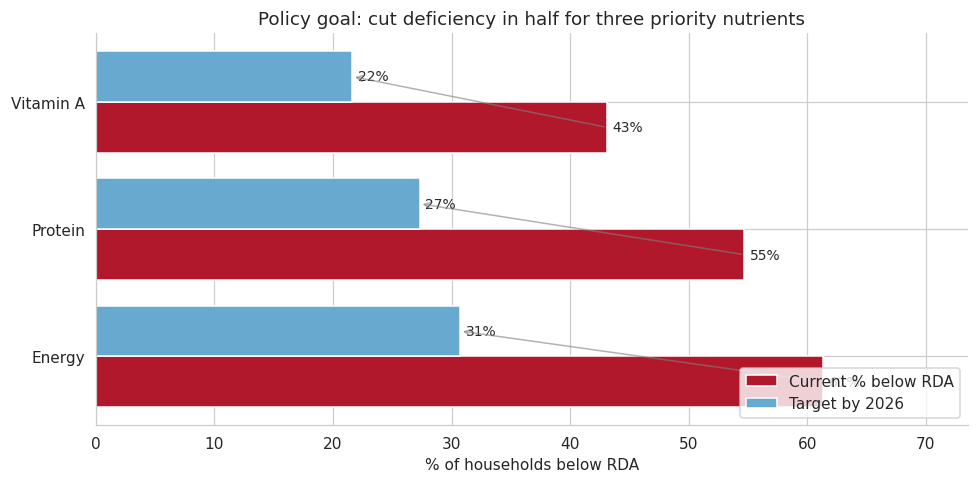

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(goal))
ax.barh(y - 0.2, goal['current_pct_deficient'], height=0.4,
        color='#B2182B', label='Current % below RDA')
ax.barh(y + 0.2, goal['target_pct_deficient'], height=0.4,
        color='#67A9CF', label='Target by 2026')

for i, (cur, tgt) in enumerate(zip(goal['current_pct_deficient'],
                                    goal['target_pct_deficient'])):
    ax.text(cur + 0.5, i - 0.2, f'{cur:.0f}%', va='center', fontsize=9)
    ax.text(tgt + 0.5, i + 0.2, f'{tgt:.0f}%', va='center', fontsize=9)
    ax.annotate('', xy=(tgt, i + 0.2), xytext=(cur, i - 0.2),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6))

ax.set_yticks(y)
ax.set_yticklabels(goal.index)
ax.set_xlim(0, max(goal['current_pct_deficient']) * 1.2)
ax.set_xlabel('% of households below RDA')
ax.set_title('Policy goal: cut deficiency in half for three priority nutrients')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()


## 16. Summary

| Finding                                                                | Evidence                                       |
|-------------------------------------------------------------------------|-----------------------------------------------|
| Calcium, Vitamin D, Vitamin B-12 universally deficient                  | 90-98% below RDA                              |
| Half of households are calorie- and protein-short                       | 52% below RDA on Energy, 43% on Protein        |
| Most households face *multiple* simultaneous gaps                        | Median household below RDA on 8 of 13 nutrients |
| Rural households disadvantaged on diversity-dependent nutrients          | See gap chart in §11                           |
| Three nutrients show the steepest urban premium (Vit A, B-12, Vit C)     | See heatmap in §10                            |

These findings motivate the policy goal in §15: **halve the deficiency
rate on Energy, Protein, and Vitamin A within five years**, with explicit
sub-targets for rural-urban equity and multi-deficiency.

The accompanying counterfactual deliverables (B–D) will test which
interventions — expenditure transfers, price subsidies on specific
staples, fortification — close these gaps most efficiently.

---

### Re-running the tests after a code change

If you edit any of the pipeline functions in §3, just re-run the cells in
§4. The test suite uses `assert result.wasSuccessful()` so any failure
will halt the notebook and tell you exactly which test broke before any
chart is regenerated from now-broken code.

To add a new test, follow this pattern in §4.3:

```python
def test_my_new_check(self):
    out = some_function(synthetic_input)
    self.assertEqual(out, expected_value_computed_by_hand)
```
